In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Absenteeism_at_work.csv to Absenteeism_at_work.csv


In [ ]:
import pandas as pd

df = pd.read_csv("Absenteeism_at_work.csv", sep=';')
df.head()


,ID,Reason for absence,Month of absence,Day of the week,Seasons,Transportation expense,Distance from Residence to Work,Service time,Age,Work load Average/day,...,Disciplinary failure,Education,Son,Social drinker,Social smoker,Pet,Weight,Height,Body mass index,Absenteeism time in hours
0,11,26,7,3,1,289,36,13,33,239.554,...,0,1,2,1,0,1,90,172,30,4
1,36,0,7,3,1,118,13,18,50,239.554,...,1,1,1,1,0,0,98,178,31,0
2,3,23,7,4,1,179,51,18,38,239.554,...,0,1,0,1,0,0,89,170,31,2
3,7,7,7,5,1,279,5,14,39,239.554,...,0,1,2,1,1,0,68,168,24,4
4,11,23,7,5,1,289,36,13,33,239.554,...,0,1,2,1,0,1,90,172,30,2


In [ ]:

df_cleaned = df.drop(columns=["ID"])

df_cleaned.columns = [
    "reason_for_absence", "month_of_absence", "day_of_week", "season",
    "transportation_expense", "distance_to_work", "service_time", "age",
    "workload_average", "hit_target", "disciplinary_failure", "education",
    "son", "social_drinker", "social_smoker", "pet", "weight", "height",
    "bmi", "absenteeism_hours"
]

df_cleaned.head()


,reason_for_absence,month_of_absence,day_of_week,season,transportation_expense,distance_to_work,service_time,age,workload_average,hit_target,disciplinary_failure,education,son,social_drinker,social_smoker,pet,weight,height,bmi,absenteeism_hours
0,26,7,3,1,289,36,13,33,239.554,97,0,1,2,1,0,1,90,172,30,4
1,0,7,3,1,118,13,18,50,239.554,97,1,1,1,1,0,0,98,178,31,0
2,23,7,4,1,179,51,18,38,239.554,97,0,1,0,1,0,0,89,170,31,2
3,7,7,5,1,279,5,14,39,239.554,97,0,1,2,1,1,0,68,168,24,4
4,23,7,5,1,289,36,13,33,239.554,97,0,1,2,1,0,1,90,172,30,2


In [ ]:
season_map = {1: "summer", 2: "autumn", 3: "winter", 4: "spring"}
day_map = {2: "Monday", 3: "Tuesday", 4: "Wednesday", 5: "Thursday", 6: "Friday"}
month_map = {0: "Unknown", 1: "January", 2: "February", 3: "March", 4: "April", 5: "May",
             6: "June", 7: "July", 8: "August", 9: "September", 10: "October", 11: "November", 12: "December"}
education_map = {1: "high_school", 2: "graduate", 3: "postgraduate", 4: "PhD"}

df_cleaned["season"] = df_cleaned["season"].map(season_map)
df_cleaned["day_of_week"] = df_cleaned["day_of_week"].map(day_map)
df_cleaned["month_of_absence"] = df_cleaned["month_of_absence"].map(month_map)
df_cleaned["education"] = df_cleaned["education"].map(education_map)


def bmi_category(bmi):
    if bmi < 18.5:
        return "underweight"
    elif 18.5 <= bmi < 25:
        return "normal"
    elif 25 <= bmi < 30:
        return "overweight"
    else:
        return "obese"

df_cleaned["bmi_category"] = df_cleaned["bmi"].apply(bmi_category)


df_cleaned["is_risky_lifestyle"] = ((df_cleaned["social_drinker"] == 1) &
                                    (df_cleaned["social_smoker"] == 1)).astype(int)


df_cleaned["is_high_absentee"] = (df_cleaned["absenteeism_hours"] > 8).astype(int)


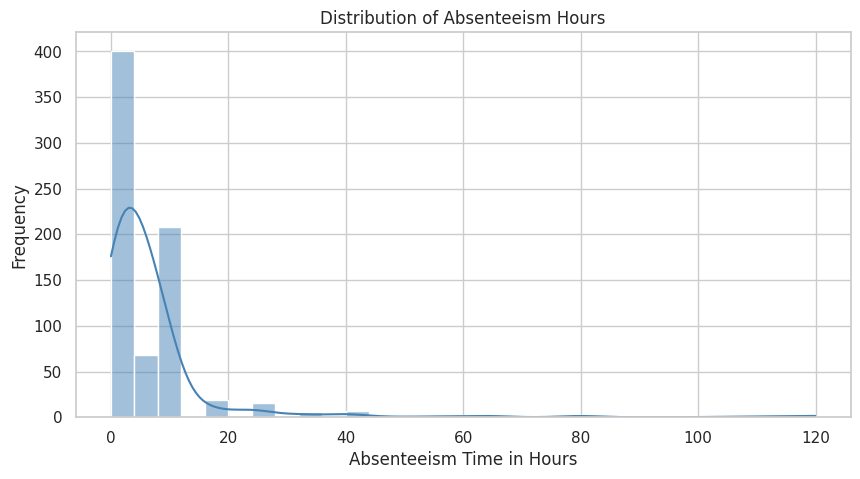

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set(style="whitegrid")

plt.figure(figsize=(10, 5))
sns.histplot(df_cleaned["absenteeism_hours"], bins=30, kde=True, color="steelblue")
plt.title("Distribution of Absenteeism Hours")
plt.xlabel("Absenteeism Time in Hours")
plt.ylabel("Frequency")
plt.show()


/tmp/ipython-input-9-3443548551.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="reason_for_absence", data=df_cleaned, order=df_cleaned["reason_for_absence"].value_counts().index, palette="viridis")


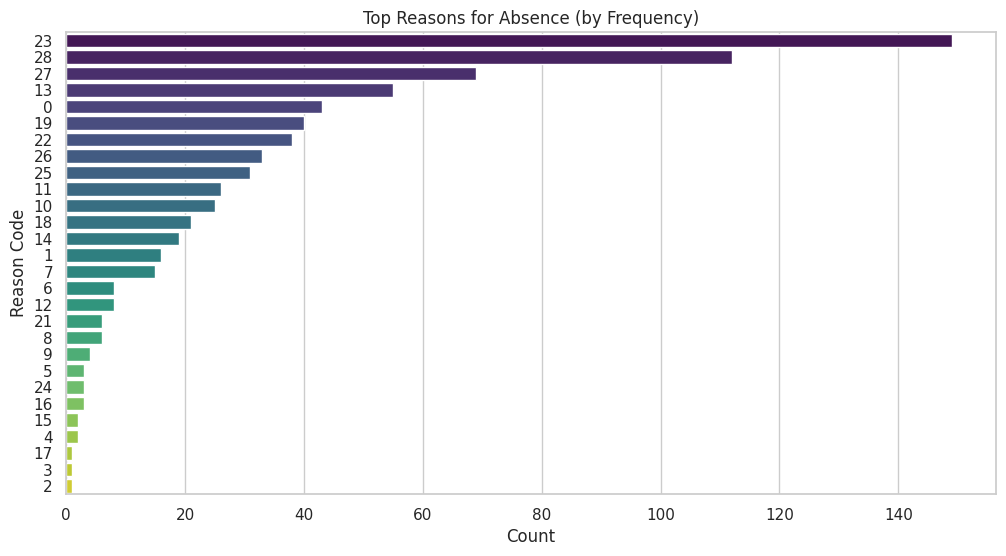

In [ ]:

plt.figure(figsize=(12, 6))
sns.countplot(y="reason_for_absence", data=df_cleaned, order=df_cleaned["reason_for_absence"].value_counts().index, palette="viridis")
plt.title("Top Reasons for Absence (by Frequency)")
plt.xlabel("Count")
plt.ylabel("Reason Code")
plt.show()


/tmp/ipython-input-12-428883355.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="bmi_category", y="absenteeism_hours", data=df_cleaned, palette="muted")


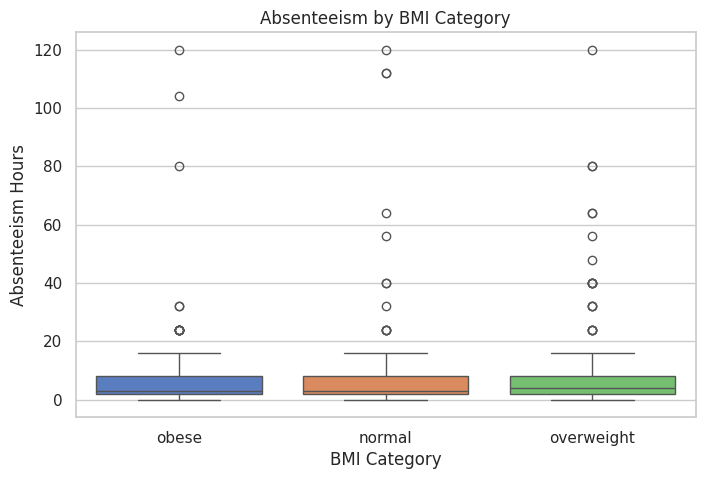

/tmp/ipython-input-12-428883355.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="is_risky_lifestyle", y="absenteeism_hours", data=df_cleaned, palette="Set1")


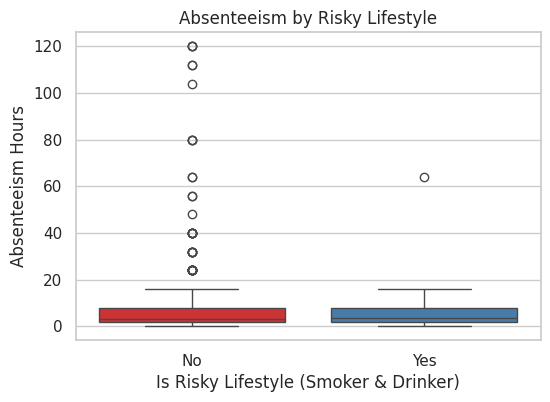

In [ ]:

plt.figure(figsize=(8, 5))
sns.boxplot(x="bmi_category", y="absenteeism_hours", data=df_cleaned, palette="muted")
plt.title("Absenteeism by BMI Category")
plt.xlabel("BMI Category")
plt.ylabel("Absenteeism Hours")
plt.show()


plt.figure(figsize=(6, 4))
sns.boxplot(x="is_risky_lifestyle", y="absenteeism_hours", data=df_cleaned, palette="Set1")
plt.title("Absenteeism by Risky Lifestyle")
plt.xlabel("Is Risky Lifestyle (Smoker & Drinker)")
plt.ylabel("Absenteeism Hours")
plt.xticks([0, 1], ["No", "Yes"])
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_cleaned.drop(columns=["absenteeism_hours", "is_high_absentee", "reason_for_absence", "bmi_category", "season", "month_of_absence", "day_of_week"])
y = df_cleaned["is_high_absentee"]

X = pd.get_dummies(X, drop_first=True)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)


rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96       137
           1       0.00      0.00      0.00        11

    accuracy                           0.93       148
   macro avg       0.46      0.50      0.48       148
weighted avg       0.86      0.93      0.89       148

Random Forest Report:
              precision    recall  f1-score   support

           0       0.92      0.93      0.92       137
           1       0.00      0.00      0.00        11

    accuracy                           0.86       148
   macro avg       0.46      0.46      0.46       148
weighted avg       0.85      0.86      0.85       148



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


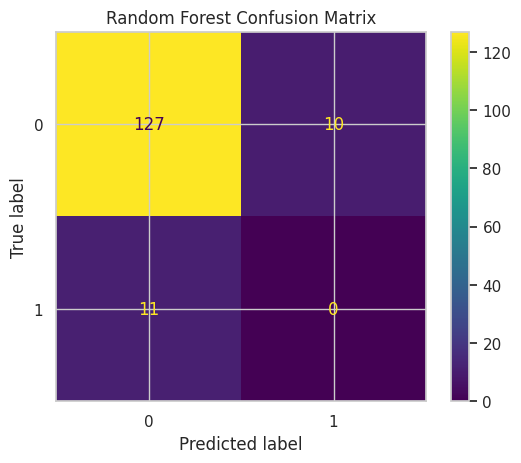

In [ ]:
print("Logistic Regression Report:")
print(classification_report(y_test, y_pred_lr))

print("Random Forest Report:")
print(classification_report(y_test, y_pred_rf))


ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
plt.title("Random Forest Confusion Matrix")
plt.show()



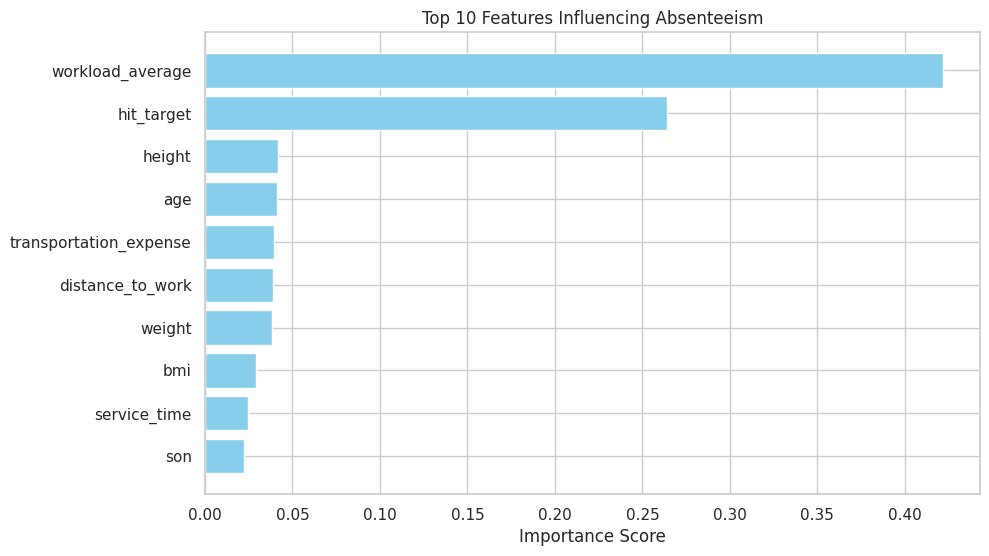

In [ ]:
import numpy as np


importances = rf.feature_importances_
features = np.array(X.columns)
sorted_idx = np.argsort(importances)[-10:]
plt.figure(figsize=(10, 6))
plt.barh(features[sorted_idx], importances[sorted_idx], color="skyblue")
plt.xlabel("Importance Score")
plt.title("Top 10 Features Influencing Absenteeism")
plt.show()


In [ ]:
df_cleaned.to_csv("absenteeism_cleaned.csv", index=False)


In [ ]:
from google.colab import files
files.download("absenteeism_cleaned.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

df_with_id = pd.read_csv("Absenteeism_at_work.csv", sep=";")
df_cleaned["ID"] = df_with_id["ID"]
df_cleaned.to_csv("absenteeism_cleaned.csv", index=False)
